Loading data for Channel: P-1...
Original Train Shape: (2872, 25)
LSTM Training Input Shape: (2772, 100, 25)
LSTM Testing Input Shape: (8405, 100, 25)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        23,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100, 64)        │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 100, 25)        │         1,625 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,689 (225.35 KB)

 Trainable params: 57,689 (225.35 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 22s 22s/step - loss: 0.0257 - val_loss: 0.0313
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - loss: 0.0249 - val_loss: 0.0305
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - loss: 0.0243 - val_loss: 0.0300
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - loss: 0.0238 - val_loss: 0.0295
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - loss: 0.0234 - val_loss: 0.0291
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - loss: 0.0231 - val_loss: 0.0288
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - loss: 0.0228 - val_loss: 0.0284
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - loss: 0.0225 - val_loss: 0.0281
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - loss: 0.0222 - val_loss: 0.0278
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - loss: 0.0219 - val_loss: 0.0275
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - loss: 0.0217 - val_loss: 0.0272
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - loss: 0.0214 - val_los

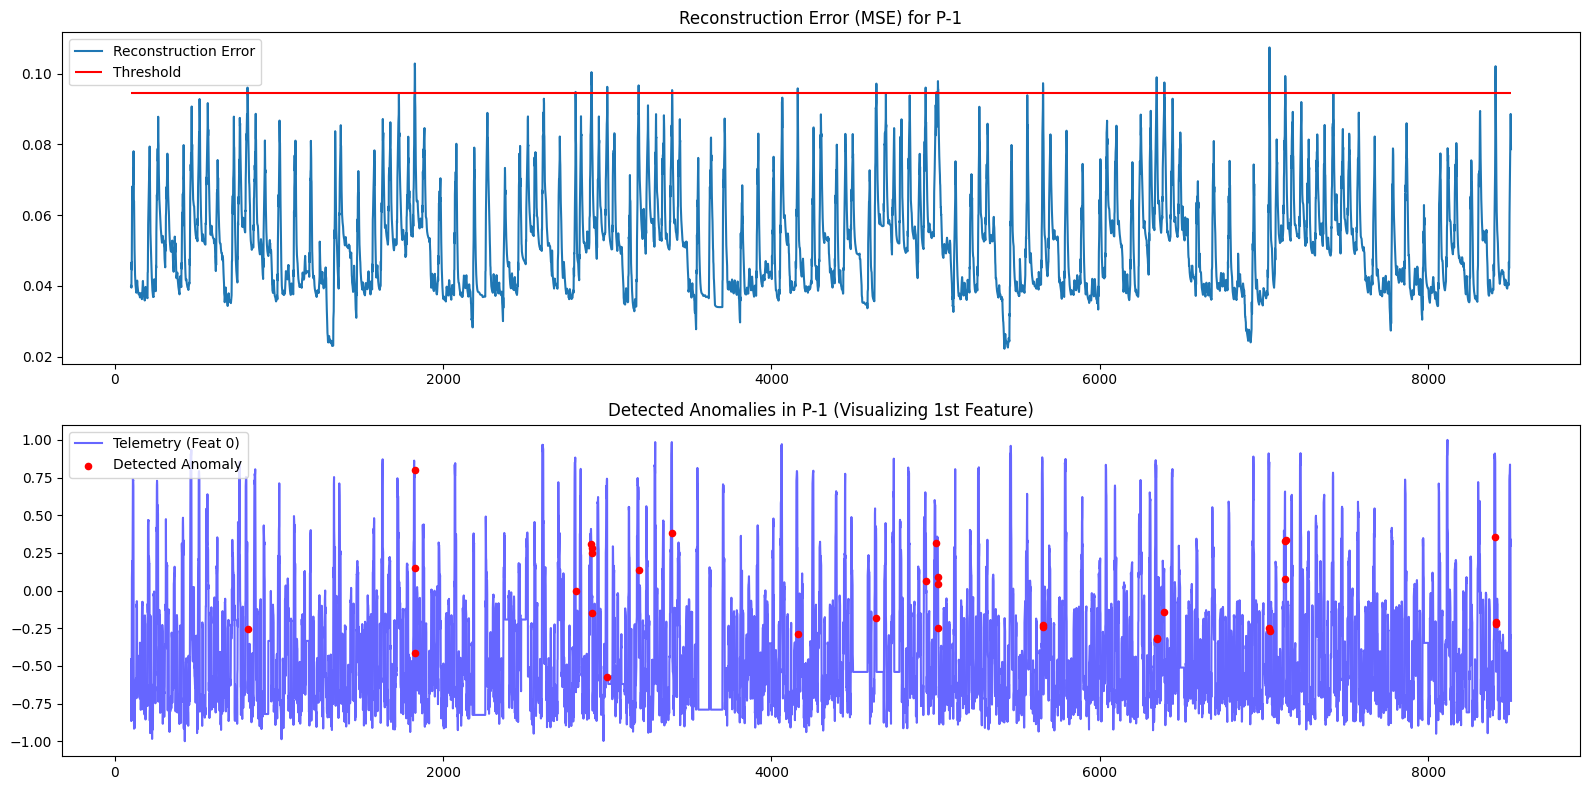


--- GROUND TRUTH ANOMALIES ---
                            anomaly_sequences
0  [[2149, 2349], [4536, 4844], [3539, 3779]]


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import os

# --- 1. CONFIGURATION ---
DATA_PATH = "/kaggle/input/nasa-anomaly-detection-dataset-smap-msl/data/data"
TRAIN_PATH = os.path.join(DATA_PATH, "train")
TEST_PATH = os.path.join(DATA_PATH, "test")
LABEL_PATH = "/kaggle/input/nasa-anomaly-detection-dataset-smap-msl/labeled_anomalies.csv"

CHANNEL_ID = 'P-1' 
TIME_STEPS = 100 

# --- 2. DATA LOADING & PROCESSING ---
def load_data(channel_id):
    """Loads .npy files without flattening dimensions"""
    try:
        train = np.load(os.path.join(TRAIN_PATH, f"{channel_id}.npy"))
        test = np.load(os.path.join(TEST_PATH, f"{channel_id}.npy"))
        return train, test
    except FileNotFoundError:
        print(f"File for {channel_id} not found.")
        return None, None

def create_sequences(values, time_steps=TIME_STEPS):
    """Generates sliding window sequences (Samples, Timesteps, Features)"""
    output = []
    for i in range(len(values) - time_steps):
        output.append(values[i : (i + time_steps)])
    return np.stack(output)

print(f"Loading data for Channel: {CHANNEL_ID}...")
train_data, test_data = load_data(CHANNEL_ID)

# FIX: Do not reshape to (-1, 1). Keep the original features (e.g., 25 columns)
# train_data shape is likely (N, 25)
print(f"Original Train Shape: {train_data.shape}")

# Scale data
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(train_data)
X_test_scaled = scaler.transform(test_data)

# Create sequences
X_train = create_sequences(X_train_scaled)
X_test = create_sequences(X_test_scaled)

print(f"LSTM Training Input Shape: {X_train.shape}") # (Samples, TimeSteps, Features)
print(f"LSTM Testing Input Shape: {X_test.shape}")

# --- 3. BUILD LSTM AUTOENCODER ---
n_features = X_train.shape[2] # Dynamically get number of features (e.g., 25)

model = Sequential([
    # Encoder
    LSTM(64, activation='relu', input_shape=(TIME_STEPS, n_features), return_sequences=False),
    RepeatVector(TIME_STEPS),
    
    # Decoder
    LSTM(64, activation='relu', return_sequences=True),
    TimeDistributed(Dense(n_features)) # Output must match input features
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# --- 4. TRAIN MODEL ---
history = model.fit(
    X_train, X_train,
    epochs=20,
    batch_size=16384,
    validation_split=0.1,
    verbose=1
)

# --- 5. DETECT ANOMALIES ---
# Predict reconstruction
X_test_pred = model.predict(X_test)

# FIX: Calculate Error across all features
# We take the mean absolute error across the TimeSteps (axis 1) AND Features (axis 2)
# This results in a single scalar loss value per data point
test_mae_loss = np.mean(np.abs(X_test_pred - X_test), axis=(1, 2))

# Define Threshold
threshold = np.mean(test_mae_loss) + 3 * np.std(test_mae_loss)
print(f"Anomaly Threshold: {threshold}")

# --- 6. VISUALIZATION ---
# We align the DataFrame with the sequence data (cutting off the first TIME_STEPS)
test_score_df = pd.DataFrame(index=range(TIME_STEPS, len(test_data)))

# Assign the loss (now the lengths match!)
test_score_df['loss'] = test_mae_loss 
test_score_df['threshold'] = threshold
test_score_df['anomaly'] = test_score_df['loss'] > test_score_df['threshold']

# For plotting only, we take the FIRST feature (column 0) of the telemetry
test_score_df['close'] = test_data[TIME_STEPS:, 0] 

plt.figure(figsize=(16, 8))

# Plot 1: Reconstruction Error
plt.subplot(2, 1, 1)
plt.plot(test_score_df.index, test_score_df['loss'], label='Reconstruction Error')
plt.hlines(threshold, test_score_df.index[0], test_score_df.index[-1], color='r', label='Threshold')
plt.title(f'Reconstruction Error (MSE) for {CHANNEL_ID}')
plt.legend()

# Plot 2: Telemetry Signal (First Feature) with Anomalies
plt.subplot(2, 1, 2)
plt.plot(test_score_df.index, test_score_df['close'], label='Telemetry (Feat 0)', color='b', alpha=0.6)

# Overlay anomalies
anomalies = test_score_df[test_score_df['anomaly'] == True]
plt.scatter(anomalies.index, anomalies['close'], color='r', label='Detected Anomaly', s=20, zorder=10)

plt.title(f'Detected Anomalies in {CHANNEL_ID} (Visualizing 1st Feature)')
plt.legend()

plt.tight_layout()
plt.show()

# --- 7. CHECK LABELS ---
labels = pd.read_csv(LABEL_PATH)
truth = labels[labels['chan_id'] == CHANNEL_ID]
print("\n--- GROUND TRUTH ANOMALIES ---")
print(truth[['anomaly_sequences']])